# 1주차 코드과제
- **코드과제 1**: MNIST Digit Classification with CNN
- **코드과제 2**: Object Detection 실습 — YOLOv1 구현하기

---
# 코드과제 1

# MNIST Digit Classification with Convolutional Neural Network (CNN)

**Discipline(s):** Computer Vision, Deep Learning

colab에서 돌릴 경우, 런타임 유형을 GPU로 변경해주세요.

## 1. Import Statements

---



In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import random

## 2. Data Preprocessing

---



The first step is to preprocess our data.

In [ ]:
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [ ]:
train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
X_train = train_dataset.data
y_train = train_dataset.targets
X_test = test_dataset.data
y_test = test_dataset.targets

print("Training Images:", X_train.shape)  # [60000, 28, 28]
print("Testing Images:", X_test.shape)    # [10000, 28, 28]
print("Training Labels:", y_train.shape)  # [60000]
print("Test Labels:", y_test.shape)       # [10000]

In [ ]:
plt.imshow(X_train[10], cmap='gray')
plt.title(f"Label: {y_train[10].item()}")
plt.axis('off')
plt.show()

## 3. Convolutional Neural Network (CNN)

---



### 3.1. Define the Model

We then have to define our convolutional neural network.

In [ ]:
# CNN 모델 정의 -> 차원이 어떻게 될지 생각하면서 코드 빈칸을 채워주세요.
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # input dimensions: (N, 1, 28, 28)
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # (N, 1, 28, 28) -> (N, 16, 28, 28)
            nn.ReLU(),                                    # activation function
            nn.MaxPool2d(2),                              # (N, 16, 28, 28) -> (N, 16, 14, 14)

            # 모델을 더 깊게 쌓아도 됩니다.
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # (N, 16, 14, 14) -> (N, 32, 14, 14)
            nn.ReLU(),
            nn.MaxPool2d(2),                              # (N, 32, 14, 14) -> (N, 32, 7, 7)

            # fully connected layer 전, flatten 과정 필요
            nn.Flatten(),                                 # (N, 32, 7, 7) -> (N, 32 * 7 * 7)
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)                             # MNIST 클래스 수 = 10
        )

    def forward(self, x):
        return self.net(x)

In [8]:
# 모델 준비
model = SimpleCNN().to(DEVICE)

Once our model is defined, we can compile it using the Adam optimizer and the categorical cross-entropy loss function.

In [ ]:
criterion = nn.CrossEntropyLoss() # log_softmax + Negative Log Likelihood Loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

### 3.2. Train the Model

In [10]:
def train(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        correct += (output.argmax(dim=1) == y).sum().item()
        total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [11]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            output = model(x)
            loss = criterion(output, y)

            total_loss += loss.item() * y.size(0)
            correct += (output.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

In [ ]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

### 3.3. 시각화

Finally, we can plot the curves.

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

## 4. Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [14]:
def show_random_predictions(model, dataset, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"GT: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Finally, we can show a random test image with its corresponding prediction.

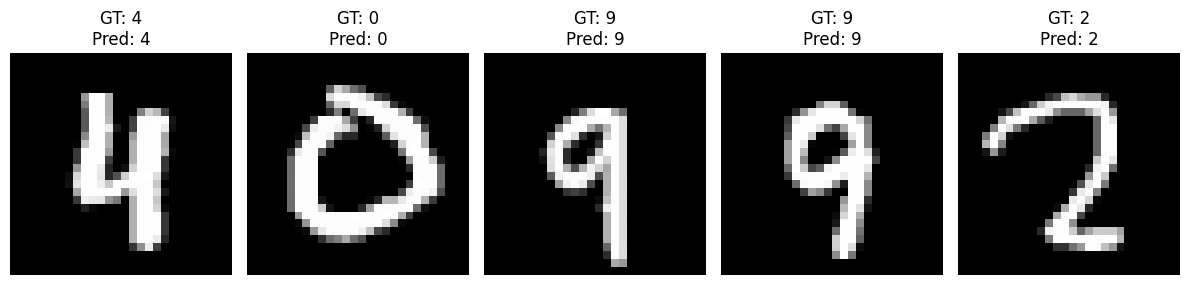

In [15]:
show_random_predictions(model, test_dataset, num_images=5)

## ResNet

In [ ]:
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        # with BatchNorm, bias has no effect
        self.bn1 = nn.BatchNorm2d(out_channels)      # batch normalization
        self.relu = nn.ReLU()                         # activation function
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # 추가로 layer 등을 더 구현하셔도 됩니다.

        # Skip connection: 채널 수가 다르면 어떤 convolution layer를 사용하는게 좋을지 생각해주세요.
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        # 빈칸 채우기
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        return self.relu(out)

In [ ]:
class ResNetLike(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # layer 등을 추가로 더 쌓으셔도 됩니다.
        self.layer1 = ResidualBlock(16, 32)
        self.layer2 = ResidualBlock(32, 64)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # 빈칸을 채워주세요.
        self.fc = nn.Linear(64, 10)

    def forward(self, x):
        # 빈칸을 채워주세요.
        x = self.stem(x)      # (N, 1, 28, 28) -> (N, 16, 14, 14)
        x = self.layer1(x)    # (N, 16, 14, 14) -> (N, 32, 14, 14)
        x = self.layer2(x)    # (N, 32, 14, 14) -> (N, 64, 14, 14)
        x = self.avgpool(x)   # (N, 64, 14, 14) -> (N, 64, 1, 1)
        x = torch.flatten(x, 1)  # (N, 64, 1, 1) -> (N, 64)
        x = self.fc(x)        # (N, 64) -> (N, 10)

        return x

In [19]:
model = ResNetLike().to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

### 시각화

Finally, we can plot the curves.

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

### Make a Prediction

---



Once our model is trained, we can use it to make predictions. To do this, we first use our test set to predict the classes.

In [23]:
def show_random_predictions(model, dataset, num_images=5):
    model.eval()

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    images = images.to(DEVICE)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f"GT: {labels[i].item()}\nPred: {preds[i].item()}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Finally, we can show a random test image with its corresponding prediction.

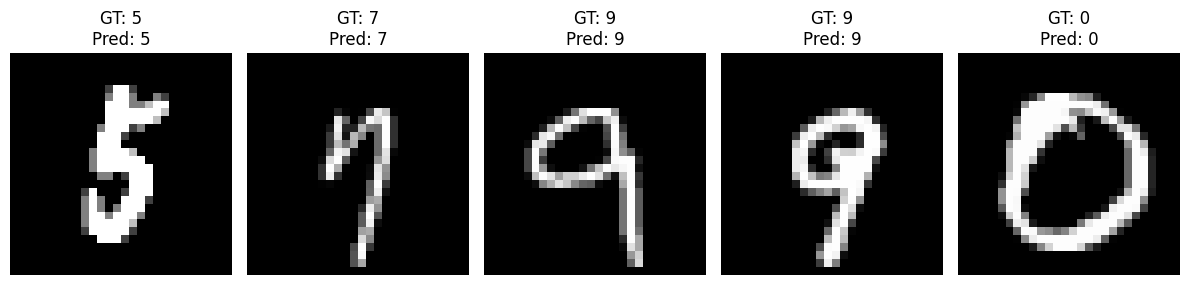

In [24]:
show_random_predictions(model, test_dataset, num_images=5)

# 다른 데이터셋으로도 진행해보기

In [ ]:
# 다른 데이터셋으로 진행해보기: CIFAR-10
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CIFAR-10은 RGB 3채널 컬러 이미지라 채널별 mean/std로 정규화합니다.
cifar_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = datasets.CIFAR10(root='./data', train=True, transform=cifar_transform, download=True)
test_dataset  = datasets.CIFAR10(root='./data', train=False, transform=cifar_transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

cifar_classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print("Training Images:", train_dataset.data.shape)  # (50000, 32, 32, 3)
print("Testing Images:", test_dataset.data.shape)     # (10000, 32, 32, 3)

In [ ]:
idx = 10
plt.imshow(train_dataset.data[idx])
plt.title(f"Label: {cifar_classes[train_dataset.targets[idx]]}")
plt.axis('off')
plt.show()

In [ ]:
# CIFAR-10은 32x32(28x28보다 큼) x 3채널이므로 SimpleCNN을 채널/차원에 맞게 조정합니다.
class CIFARCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # (N, 3, 32, 32) -> (N, 32, 32, 32)
            nn.ReLU(),
            nn.MaxPool2d(2),                                # -> (N, 32, 16, 16)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),   # -> (N, 64, 16, 16)
            nn.ReLU(),
            nn.MaxPool2d(2),                                # -> (N, 64, 8, 8)

            nn.Flatten(),                                   # -> (N, 64 * 8 * 8)
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, 10)                              # CIFAR-10 클래스 수 = 10
        )

    def forward(self, x):
        return self.net(x)

model = CIFARCNN().to(DEVICE)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader)
    test_loss, test_acc = evaluate(model, test_loader)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"[Epoch {epoch+1}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs (CIFAR-10)")
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(epochs, test_accuracies, label='Test Accuracy', marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs (CIFAR-10)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# CIFAR-10은 3채널 컬러 이미지이므로, 기존 show_random_predictions(cmap='gray' 가정)를
# 그대로 쓰면 정규화된 값이 깨진 색으로 표시됩니다. 정규화를 복원(unnormalize)하고
# (C, H, W) -> (H, W, C)로 축을 바꿔 컬러로 보여주는 버전을 새로 정의합니다.
def show_random_predictions_cifar(model, dataset, classes, num_images=5):
    model.eval()
    mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
    std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)

    indices = random.sample(range(len(dataset)), num_images)
    images = torch.stack([dataset[i][0] for i in indices])
    labels = torch.tensor([dataset[i][1] for i in indices])

    outputs = model(images.to(DEVICE))
    preds = outputs.argmax(dim=1)

    plt.figure(figsize=(12, 3))
    for i in range(num_images):
        img = (images[i] * std + mean).permute(1, 2, 0).clamp(0, 1).numpy()
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(f"GT: {classes[labels[i]]}\nPred: {classes[preds[i]]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_random_predictions_cifar(model, test_dataset, cifar_classes, num_images=5)

---
# 코드과제 2

# [Week 2] Object Detection 실습 : YOLOv1 구현하기 (Assignment)

이번 과제는 **PascalVOC 데이터셋**을 사용하여 **YOLOv1** 모델을 밑바닥부터(Scratch) 구현해보는 것입니다.

**목표**:
1. YOLOv1의 **CNN 아키텍처**를 직접 구현합니다.
2. YOLOv1의 핵심인 **Loss Function** (Localization, Confidence, Class Probability)을 구현합니다.
3. PascalVOC 데이터셋으로 모델을 학습시키고 결과를 확인합니다.

**참고**:
- Colab에서 실행 시 **런타임 > 런타임 유형 변경 > 하드웨어 가속기**를 **GPU**로 설정해주세요.
---

In [ ]:
## 1. Import Statements

import os, subprocess
from collections import Counter

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.notebook import tqdm
import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import torchvision.transforms.functional as FT
from sklearn.model_selection import train_test_split

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

## 2. Data Preprocessing (PascalVOC)

Kaggle에서 PascalVOC 데이터셋을 다운로드합니다.

In [ ]:
import kagglehub, os, shutil

try:
    path = kagglehub.dataset_download("aladdinpersson/pascalvoc-yolo")
    dst  = "/content/data"
    os.makedirs(dst, exist_ok=True)
    
    # 데이터셋 이동 (Colab 환경 가정)
    if os.path.exists(dst) and not os.listdir(dst):
        subprocess.run(["mv", f"{path}/*", dst], shell=True, check=True)
        final_path = dst
    else:
        final_path = path # 로컬 등 다른 환경일 경우
        
    print(f"Data Path: {final_path}")
except Exception as e:
    print(f"Error downloading/moving data: {e}")
    # 로컬 테스트용 경로 설정 (필요 시 수정)
    final_path = "./data/pascalvoc-yolo" 

# 경로 설정
img_dir = os.path.join(final_path, "images")
label_dir = os.path.join(final_path, "labels")
total_train_csv = os.path.join(final_path, "train.csv")
test_csv = os.path.join(final_path, "test.csv")

# Train/Valid Split
if os.path.exists(total_train_csv):
    df = pd.read_csv(total_train_csv)
    train_df, val_df = train_test_split(df, test_size=0.1, random_state=42)
    train_df.to_csv("train.csv", index=False)
    val_df.to_csv("valid.csv", index=False)
else:
    print("Warning: train.csv not found. Check dataset path.")

## 3. Model Implementation (YOLOv1)

YOLOv1의 아키텍처를 구현합니다. 논문에 나온 구조를 참고하여 `CNNBlock`과 `Yolov1` 클래스를 완성하세요.

### [TODO 1] YOLOv1 모델 구조 구현

In [ ]:
# YOLOv1 Architecture Configuration
architecture_config = [
    (7, 64, 2, 3), # (kernel_size, num_filters, stride, padding)
    "M",           # MaxPool
    (3, 192, 1, 1),
    "M",
    (1, 128, 1, 0),
    (3, 256, 1, 1),
    (1, 256, 1, 0),
    (3, 512, 1, 1),
    "M",
    [(1, 256, 1, 0), (3, 512, 1, 1), 4], # [Tuple1, Tuple2, repeat]
    (1, 512, 1, 0),
    (3, 1024, 1, 1),
    "M",
    [(1, 512, 1, 0), (3, 1024, 1, 1), 2],
    (3, 1024, 1, 1),
    (3, 1024, 2, 1),
    (3, 1024, 1, 1),
    (3, 1024, 1, 1),
]

class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        # -------------------------
        # [TODO] Conv2d -> BatchNorm2d -> LeakyReLU(0.1) 순서로 레이어 정의
        # 힌트: bias는 BatchNorm을 사용할 경우 False로 설정하는 것이 일반적입니다.

        self.conv = nn.Conv2d(in_channels, out_channels, bias=False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(0.1)
        # -------------------------

    def forward(self, x):
        # [TODO] Forward pass 구현
        return self.leakyrelu(self.batchnorm(self.conv(x)))

class Yolov1(nn.Module):
    def __init__(self, in_channels=3, **kwargs):
        super(Yolov1, self).__init__()
        self.architecture = architecture_config
        self.in_channels = in_channels
        
        # [TODO] Darknet (Conv Layers) 생성
        self.darknet = self._create_conv_layers(self.architecture)
        
        # [TODO] Fully Connected Layers 생성
        self.fcs = self._create_fcs(**kwargs)

    def forward(self, x):
        # [TODO] Forward Pass 구현
        # 1. Darknet 통과
        # 2. Flatten
        # 3. FC Layers 통과
        x = self.darknet(x)
        x = self.fcs(x)
        return x

    def _create_conv_layers(self, architecture):
        layers = []
        in_channels = self.in_channels

        for x in architecture:
            if type(x) == tuple:
                # (kernel_size, num_filters, stride, padding)
                # [TODO] CNNBlock 추가
                layers.append(
                    CNNBlock(
                        in_channels,
                        x[1],
                        kernel_size=x[0],
                        stride=x[2],
                        padding=x[3],
                    )
                )
                in_channels = x[1]
            elif type(x) == str:
                # "M" -> MaxPool
                # [TODO] MaxPool2d 추가
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            elif type(x) == list:
                # [Tuple1, Tuple2, repeat]
                # [TODO] 반복되는 블록 추가
                conv1 = x[0]
                conv2 = x[1]
                num_repeats = x[2]

                for _ in range(num_repeats):
                    layers.append(
                        CNNBlock(
                            in_channels,
                            conv1[1],
                            kernel_size=conv1[0],
                            stride=conv1[2],
                            padding=conv1[3],
                        )
                    )
                    layers.append(
                        CNNBlock(
                            conv1[1],
                            conv2[1],
                            kernel_size=conv2[0],
                            stride=conv2[2],
                            padding=conv2[3],
                        )
                    )
                    in_channels = conv2[1]
                
        return nn.Sequential(*layers)

    def _create_fcs(self, split_size, num_boxes, num_classes):
        # YOLOv1의 마지막 FC Layer 구조: Flatten -> FC(4096) -> LeakyReLU -> FC(S*S*(C+B*5))
        S, B, C = split_size, num_boxes, num_classes
        
        # [TODO] Sequential 모델로 FC Layer 구성
        return nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * S * S, 496),
            nn.Dropout(0.0),
            nn.LeakyReLU(0.1),
            nn.Linear(496, S * S * (C + B * 5)),
        )

## 4. Loss Function Implementation

YOLOv1 Loss는 5개의 부분으로 구성됩니다:
1. **Coordinate Loss** (Box Center x, y)
2. **Coordinate Loss** (Box Width, Height - Sqrt 적용)
3. **Object Confidence Loss** (객체가 있을 때)
4. **No Object Confidence Loss** (객체가 없을 때)
5. **Class Probability Loss**

### [TODO 2] YOLOv1 Loss 함수 구현

In [ ]:
class YoloLoss(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super(YoloLoss, self).__init__()
        self.mse = nn.MSELoss(reduction="sum")
        self.S = S
        self.B = B
        self.C = C
        self.lambda_noobj = 0.5
        self.lambda_coord = 5

    def forward(self, predictions, target):
        # predictions shape: (BATCH_SIZE, S*S*(C+B*5))
        # target shape: (BATCH_SIZE, S, S, C+5)
        predictions = predictions.reshape(-1, self.S, self.S, self.C + self.B * 5)

        # ------------------------------------------------------
        # 1. IoU 계산 및 Responsible Box 찾기
        # ------------------------------------------------------
        # predictions[..., 21:25] -> Box 1 (x, y, w, h)
        # predictions[..., 26:30] -> Box 2 (x, y, w, h)

        # [TODO] 각 박스와 Target 박스 간의 IoU 계산
        iou_b1 = intersection_over_union(predictions[..., 21:25], target[..., 21:25])
        iou_b2 = intersection_over_union(predictions[..., 26:30], target[..., 21:25])
        ious = torch.cat([iou_b1.unsqueeze(0), iou_b2.unsqueeze(0)], dim=0)

        # [TODO] 두 박스 중 IoU가 더 높은 박스를 선택 (Responsible Box)
        iou_maxes, bestbox = torch.max(ious, dim=0)
        exists_box = target[..., 20].unsqueeze(3)  # Iobj_i

        # ------------------------------------------------------
        # 2. Box Coordinates Loss
        # ------------------------------------------------------
        # [TODO] Box 좌표 (x, y, w, h)에 대한 MSE Loss 계산
        # 주의: w, h는 sqrt를 취한 후 차이를 구해야 함
        box_predictions = exists_box * (
            bestbox * predictions[..., 26:30]
            + (1 - bestbox) * predictions[..., 21:25]
        )
        box_targets = exists_box * target[..., 21:25]

        box_predictions[..., 2:4] = torch.sign(box_predictions[..., 2:4]) * torch.sqrt(
            torch.abs(box_predictions[..., 2:4] + 1e-6)
        )
        box_targets[..., 2:4] = torch.sqrt(box_targets[..., 2:4])

        box_loss = self.mse(
            torch.flatten(box_predictions, end_dim=-2),
            torch.flatten(box_targets, end_dim=-2),
        )

        # ------------------------------------------------------
        # 3. Object Loss
        # ------------------------------------------------------
        # [TODO] 객체가 있는 셀의 Confidence Score에 대한 Loss
        pred_box = (
            bestbox * predictions[..., 25:26] + (1 - bestbox) * predictions[..., 20:21]
        )

        object_loss = self.mse(
            torch.flatten(exists_box * pred_box),
            torch.flatten(exists_box * target[..., 20:21]),
        )

        # ------------------------------------------------------
        # 4. No Object Loss
        # ------------------------------------------------------
        # [TODO] 객체가 없는 셀(및 Responsible이 아닌 박스)의 Confidence Loss
        no_object_loss = self.mse(
            torch.flatten((1 - exists_box) * predictions[..., 20:21], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., 20:21], start_dim=1),
        )

        no_object_loss += self.mse(
            torch.flatten((1 - exists_box) * predictions[..., 25:26], start_dim=1),
            torch.flatten((1 - exists_box) * target[..., 20:21], start_dim=1),
        )

        # ------------------------------------------------------
        # 5. Class Loss
        # ------------------------------------------------------
        # [TODO] Class Probability에 대한 Loss
        class_loss = self.mse(
            torch.flatten(exists_box * predictions[..., :20], end_dim=-2),
            torch.flatten(exists_box * target[..., :20], end_dim=-2),
        )

        loss = (
            self.lambda_coord * box_loss
            + object_loss
            + self.lambda_noobj * no_object_loss
            + class_loss
        )

        return loss

## 5. Utils (IoU, NMS, mAP)

Object Detection에 필요한 유틸리티 함수들입니다. (이미 구현되어 있음)

In [ ]:
def intersection_over_union(boxes_preds, boxes_labels, box_format="midpoint"):
    # ... (생략된 IoU 코드, 실제로는 이 셀에 전체 코드를 넣어야 함) ...
    if box_format == "midpoint":
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2
        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2
    elif box_format == "corners":
        box1_x1, box1_y1, box1_x2, box1_y2 = boxes_preds[..., 0:1], boxes_preds[..., 1:2], boxes_preds[..., 2:3], boxes_preds[..., 3:4]
        box2_x1, box2_y1, box2_x2, box2_y2 = boxes_labels[..., 0:1], boxes_labels[..., 1:2], boxes_labels[..., 2:3], boxes_labels[..., 3:4]

    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)

    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    box1_area = torch.abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = torch.abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))

    return intersection / (box1_area + box2_area - intersection + 1e-6)

def non_max_suppression(bboxes, iou_threshold, threshold, box_format="midpoint"):
    assert type(bboxes) == list

    bboxes = [box for box in bboxes if box[1] > threshold]
    bboxes = sorted(bboxes, key=lambda x: x[1], reverse=True)
    bboxes_after_nms = []

    while bboxes:
        chosen_box = bboxes.pop(0)

        bboxes = [
            box
            for box in bboxes
            if box[0] != chosen_box[0]
            or intersection_over_union(
                torch.tensor(chosen_box[2:]),
                torch.tensor(box[2:]),
                box_format=box_format,
            )
            < iou_threshold
        ]

        bboxes_after_nms.append(chosen_box)

    return bboxes_after_nms

def mean_average_precision(pred_boxes, true_boxes, iou_threshold=0.5, box_format="midpoint", num_classes=20):
    # pred_boxes / true_boxes: [train_idx, class_pred, prob_score, x1, y1, x2, y2] 형태의 리스트
    average_precisions = []
    epsilon = 1e-6

    for c in range(num_classes):
        detections = [d for d in pred_boxes if d[1] == c]
        ground_truths = [g for g in true_boxes if g[1] == c]

        # 이미지(train_idx)별 정답 박스 개수만큼 "아직 매칭 안 됨(0)" 표시를 미리 만들어둠
        amount_bboxes = Counter([gt[0] for gt in ground_truths])
        for key, val in amount_bboxes.items():
            amount_bboxes[key] = torch.zeros(val)

        # confidence(prob_score) 내림차순 정렬: 자신 있는 예측부터 먼저 매칭 시도
        detections.sort(key=lambda x: x[2], reverse=True)
        TP = torch.zeros((len(detections)))
        FP = torch.zeros((len(detections)))
        total_true_bboxes = len(ground_truths)

        if total_true_bboxes == 0:
            continue

        for detection_idx, detection in enumerate(detections):
            ground_truth_img = [bbox for bbox in ground_truths if bbox[0] == detection[0]]

            best_iou = 0
            best_gt_idx = -1
            for idx, gt in enumerate(ground_truth_img):
                iou = intersection_over_union(
                    torch.tensor(detection[3:]),
                    torch.tensor(gt[3:]),
                    box_format=box_format,
                )
                if iou > best_iou:
                    best_iou = iou
                    best_gt_idx = idx

            if best_iou > iou_threshold:
                # 아직 다른 예측이 이 정답 박스를 선점하지 않았을 때만 True Positive
                if amount_bboxes[detection[0]][best_gt_idx] == 0:
                    TP[detection_idx] = 1
                    amount_bboxes[detection[0]][best_gt_idx] = 1
                else:
                    FP[detection_idx] = 1
            else:
                FP[detection_idx] = 1

        TP_cumsum = torch.cumsum(TP, dim=0)
        FP_cumsum = torch.cumsum(FP, dim=0)
        recalls = TP_cumsum / (total_true_bboxes + epsilon)
        precisions = TP_cumsum / (TP_cumsum + FP_cumsum + epsilon)

        # (recall=0, precision=1)을 시작점으로 추가한 뒤 PR 곡선 아래 면적(AP)을 적분으로 계산
        precisions = torch.cat((torch.tensor([1]), precisions))
        recalls = torch.cat((torch.tensor([0]), recalls))
        average_precisions.append(torch.trapz(precisions, recalls))

    return sum(average_precisions) / len(average_precisions)

## 6. Training Loop

모델을 학습시키는 Loop입니다.

In [ ]:
def convert_cellboxes(predictions, S=7):
    # 모델 출력(셀 기준 상대 좌표, 2박스 중 confidence 높은 박스)을
    # 이미지 전체 기준 (x, y, w, h) 좌표로 변환합니다.
    predictions = predictions.to("cpu")
    batch_size = predictions.shape[0]
    predictions = predictions.reshape(batch_size, S, S, 30)
    bboxes1 = predictions[..., 21:25]
    bboxes2 = predictions[..., 26:30]
    scores = torch.cat(
        (predictions[..., 20].unsqueeze(0), predictions[..., 25].unsqueeze(0)), dim=0
    )
    best_box = scores.argmax(0).unsqueeze(-1)
    best_boxes = bboxes1 * (1 - best_box) + best_box * bboxes2

    cell_indices = torch.arange(S).repeat(batch_size, S, 1).unsqueeze(-1)
    x = 1 / S * (best_boxes[..., :1] + cell_indices)
    y = 1 / S * (best_boxes[..., 1:2] + cell_indices.permute(0, 2, 1, 3))
    w_y = 1 / S * best_boxes[..., 2:4]
    converted_bboxes = torch.cat((x, y, w_y), dim=-1)

    predicted_class = predictions[..., :20].argmax(-1).unsqueeze(-1)
    best_confidence = torch.max(predictions[..., 20], predictions[..., 25]).unsqueeze(-1)
    converted_preds = torch.cat((predicted_class, best_confidence, converted_bboxes), dim=-1)

    return converted_preds


def cellboxes_to_boxes(out, S=7):
    converted_pred = convert_cellboxes(out, S).reshape(out.shape[0], S * S, -1)
    converted_pred[..., 0] = converted_pred[..., 0].long()
    all_bboxes = []

    for ex_idx in range(out.shape[0]):
        bboxes = []
        for bbox_idx in range(S * S):
            bboxes.append([x.item() for x in converted_pred[ex_idx, bbox_idx, :]])
        all_bboxes.append(bboxes)

    return all_bboxes


def get_bboxes(loader, model, iou_threshold, threshold, box_format="midpoint", device="cpu"):
    # 배치 단위 모델 예측을 NMS까지 적용한 (train_idx 포함) 박스 리스트로 모아
    # mean_average_precision에 바로 넣을 수 있는 형태로 만들어줍니다.
    all_pred_boxes = []
    all_true_boxes = []

    model.eval()
    train_idx = 0

    for x, labels in loader:
        x = x.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            predictions = model(x)

        batch_size = x.shape[0]
        true_bboxes = cellboxes_to_boxes(labels)
        bboxes = cellboxes_to_boxes(predictions)

        for idx in range(batch_size):
            nms_boxes = non_max_suppression(
                bboxes[idx], iou_threshold=iou_threshold, threshold=threshold, box_format=box_format
            )

            for nms_box in nms_boxes:
                all_pred_boxes.append([train_idx] + nms_box)

            for box in true_bboxes[idx]:
                if box[1] > threshold:
                    all_true_boxes.append([train_idx] + box)

            train_idx += 1

    model.train()
    return all_pred_boxes, all_true_boxes


class Compose:
    # torchvision.transforms는 이미지만 다루지만, object detection은
    # 이미지가 변형될 때 bbox 좌표도 함께 다뤄야 하므로 (img, bboxes) 쌍을 받는 wrapper가 필요합니다.
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, bboxes):
        for t in self.transforms:
            img = t(img)
        return img, bboxes


transform = Compose([transforms.Resize((448, 448)), transforms.ToTensor()])


class VOCDataset(Dataset):
    def __init__(self, csv_file, img_dir, label_dir, S=7, B=2, C=20, transform=None):
        self.annotations = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.S = S
        self.B = B
        self.C = C

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        label_path = os.path.join(self.label_dir, self.annotations.iloc[index, 1])
        boxes = []
        with open(label_path) as f:
            for label in f.readlines():
                class_label, x, y, width, height = [
                    float(v) if float(v) != int(float(v)) else int(v)
                    for v in label.replace("\n", "").split()
                ]
                boxes.append([class_label, x, y, width, height])

        img_path = os.path.join(self.img_dir, self.annotations.iloc[index, 0])
        image = Image.open(img_path)
        boxes = torch.tensor(boxes)

        if self.transform:
            image, boxes = self.transform(image, boxes)

        # (x, y, w, h)가 이미지 전체 기준 상대좌표(0~1)로 주어지므로,
        # 어느 그리드 셀(i, j)에 속하는지 계산하고 그 셀 내부 상대좌표(x_cell, y_cell)로 다시 변환합니다.
        label_matrix = torch.zeros((self.S, self.S, self.C + 5 * self.B))
        for box in boxes:
            class_label, x, y, width, height = box.tolist()
            class_label = int(class_label)

            i, j = int(self.S * y), int(self.S * x)
            x_cell, y_cell = self.S * x - j, self.S * y - i
            width_cell, height_cell = width * self.S, height * self.S

            # 한 셀에는 박스를 하나만 할당(YOLOv1의 한계) - 이미 채워진 셀이면 skip
            if label_matrix[i, j, 20] == 0:
                label_matrix[i, j, 20] = 1
                box_coordinates = torch.tensor([x_cell, y_cell, width_cell, height_cell])
                label_matrix[i, j, 21:25] = box_coordinates
                label_matrix[i, j, class_label] = 1

        return image, label_matrix


def train_fn(train_loader, model, optimizer, loss_fn):
    loop = tqdm(train_loader, leave=True)
    mean_loss = []

    for batch_idx, (x, y) in enumerate(loop):
        x, y = x.to(device), y.to(device)
        out = model(x)
        loss = loss_fn(out, y)
        mean_loss.append(loss.item())

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loop.set_postfix(loss=loss.item())

    print(f"Mean loss was {sum(mean_loss) / len(mean_loss):.4f}")


def main():
    YOLO_BATCH_SIZE = 16
    YOLO_EPOCHS = 5

    model = Yolov1(split_size=7, num_boxes=2, num_classes=20).to(device)
    optimizer = optim.Adam(model.parameters(), lr=2e-5, weight_decay=0)
    loss_fn = YoloLoss()

    train_dataset = VOCDataset(
        "train.csv", img_dir=img_dir, label_dir=label_dir, transform=transform
    )
    valid_dataset = VOCDataset(
        "valid.csv", img_dir=img_dir, label_dir=label_dir, transform=transform
    )

    train_loader = DataLoader(
        dataset=train_dataset,
        batch_size=YOLO_BATCH_SIZE,
        shuffle=True,
        drop_last=True,
    )
    valid_loader = DataLoader(
        dataset=valid_dataset,
        batch_size=YOLO_BATCH_SIZE,
        shuffle=False,
        drop_last=True,
    )

    for epoch in range(YOLO_EPOCHS):
        pred_boxes, target_boxes = get_bboxes(
            train_loader, model, iou_threshold=0.5, threshold=0.4, device=device
        )
        mean_avg_prec = mean_average_precision(
            pred_boxes, target_boxes, iou_threshold=0.5, box_format="midpoint"
        )
        print(f"[Epoch {epoch+1}/{YOLO_EPOCHS}] Train mAP: {mean_avg_prec:.4f}")

        train_fn(train_loader, model, optimizer, loss_fn)


if __name__ == "__main__":
    main()